## Cambridge Crime Data Cleaning and Exploratory Data Analysis

The objective of this project is to clean and analyze crime reports from Cambridge, Massachusetts to identify crime patterns, trends, and high-crime areas through exploratory data analysis (EDA).

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset

In [2]:
df=pd.read_csv("Cambridge_crime_dataset.csv")

df.head()

,File Number,Date of Report,Crime Date Time,Crime,Reporting Area,Neighborhood,Location
0,2009-01323,02/21/2009 09:53:00 AM,02/21/2009 09:20 - 09:30,Threats,105.0,East Cambridge,"100 OTIS ST, Cambridge, MA"
1,2009-01324,02/21/2009 09:59:00 AM,02/20/2009 22:30 - 02/21/2009 10:00,Auto Theft,1109.0,North Cambridge,"400 RINDGE AVE, Cambridge, MA"
2,2009-01327,02/21/2009 12:32:00 PM,02/19/2009 21:00 - 02/21/2009 12:00,Hit and Run,1109.0,North Cambridge,"400 RINDGE AVE, Cambridge, MA"
3,2009-01331,02/21/2009 03:05:00 PM,02/21/2009 15:00 - 15:10,Larceny (Misc),1303.0,Strawberry Hill,"0 NORUMBEGA ST, Cambridge, MA"
4,2009-01346,02/22/2009 05:02:00 AM,02/22/2009 05:02,OUI,105.0,East Cambridge,"FIFTH ST & GORE ST, Cambridge, MA"


### Dataset overview

In [3]:
df.shape

(95923, 7)

In [4]:
df.columns

Index(['File Number', 'Date of Report', 'Crime Date Time', 'Crime',
       'Reporting Area', 'Neighborhood', 'Location'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95923 entries, 0 to 95922
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   File Number      95923 non-null  object 
 1   Date of Report   95923 non-null  object 
 2   Crime Date Time  95912 non-null  object 
 3   Crime            95923 non-null  object 
 4   Reporting Area   95915 non-null  float64
 5   Neighborhood     95915 non-null  object 
 6   Location         95628 non-null  object 
dtypes: float64(1), object(6)
memory usage: 5.1+ MB


In [6]:
df.describe(include='all')

,File Number,Date of Report,Crime Date Time,Crime,Reporting Area,Neighborhood,Location
count,95923,95923,95912,95923,95915.000000,95915,95628
unique,95923,95114,95374,54,NaN,13,5143
top,2009-01323,10/30/2014 04:45:00 PM,10/30/2014 03:06 - 04:06,Hit and Run,NaN,Cambridgeport,"100 CAMBRIDGESIDE PL, Cambridge, MA"
freq,1,3,16,9150,NaN,14496,3133
mean,NaN,NaN,NaN,NaN,632.548892,NaN,NaN
std,NaN,NaN,NaN,NaN,336.783879,NaN,NaN
min,NaN,NaN,NaN,NaN,101.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,406.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,604.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,912.000000,NaN,NaN


#### Observation
The dataset contains 95,923 crime records and 7 attributes describing crime type, date, neighborhood, reporting area, and location.

### Check Missing values

In [7]:
df.isnull().sum()

File Number          0
Date of Report       0
Crime Date Time     11
Crime                0
Reporting Area       8
Neighborhood         8
Location           295
dtype: int64

#### Observation
A small number of missing values exist in location and neighborhood-related columns.

### Data Cleaning

In [8]:
df.dropna(inplace=True)

In [9]:
# Verify
df.isnull().sum()

File Number        0
Date of Report     0
Crime Date Time    0
Crime              0
Reporting Area     0
Neighborhood       0
Location           0
dtype: int64

Missing values were removed to improve data quality.

### Check Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

No dupliacte values found in the dataset

### Exploratory Data Analysis (EDA)

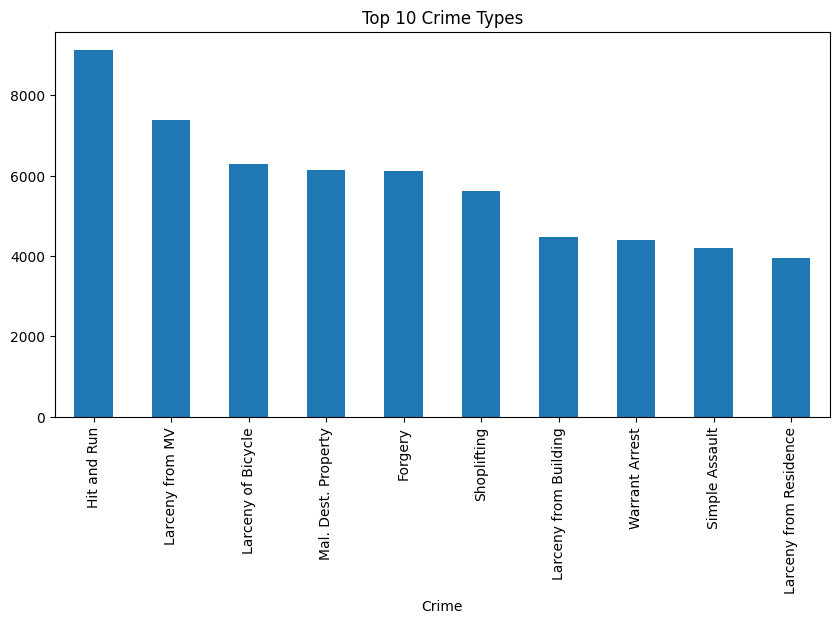

In [11]:
# 1. Top 10 Crime types
plt.figure(figsize=(10,5))
df['Crime'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.show()

The chart shows the most frequently reported crimes in Cambridge.

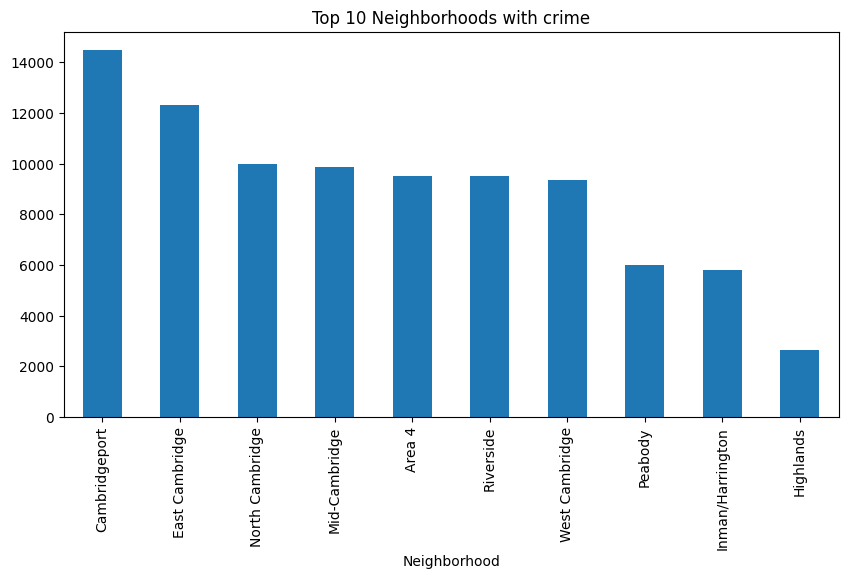

In [12]:
# 2. Top Neighborhoods with crime
plt.figure(figsize=(10,5))
df['Neighborhood'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Neighborhoods with crime")
plt.show()

Certain neighborhoods experience significantly higher crime activity than others.

In [30]:
df=pd.read_csv("Cambridge_crime_dataset.csv")

In [31]:
print(df['Crime Date Time'].head(20))

0                02/21/2009 09:20 - 09:30
1     02/20/2009 22:30 - 02/21/2009 10:00
2     02/19/2009 21:00 - 02/21/2009 12:00
3                02/21/2009 15:00 - 15:10
4                        02/22/2009 05:02
5                02/22/2009 21:39 - 21:45
6     02/20/2009 20:00 - 02/23/2009 10:00
7                02/23/2009 11:00 - 11:20
8                        02/23/2009 20:16
9     02/22/2009 19:30 - 02/23/2009 20:30
10               02/24/2009 12:15 - 12:30
11    11/29/2008 12:00 - 01/19/2009 12:00
12    02/24/2009 21:00 - 02/25/2009 02:00
13               02/24/2009 12:15 - 12:30
14                       02/25/2009 13:51
15                       02/25/2009 13:47
16               02/25/2009 16:06 - 16:10
17                       02/20/2009 00:10
18               02/25/2009 13:00 - 14:00
19    02/25/2009 18:00 - 02/26/2009 07:30
Name: Crime Date Time, dtype: object


In [35]:
df['Crime_Start']= df['Crime Date Time'].str.split(' - ').str[0]

In [36]:
df['Crime_Start'].head()

0    02/21/2009 09:20
1    02/20/2009 22:30
2    02/19/2009 21:00
3    02/21/2009 15:00
4    02/22/2009 05:02
Name: Crime_Start, dtype: object

In [37]:
df['Crime_Start']=pd.to_datetime(df['Crime_Start'], format='%m%d%Y %H:%M', errors='coerce')

In [38]:
# Extract year
df['Year']=df['Crime_Start'].dt.year
# Extract month
df['Month']=df['Crime_Start'].dt.month

In [41]:
df['Crime_Start'].head()

0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: Crime_Start, dtype: datetime64[ns]

In [42]:
df['Crime_Start'].isnull().sum()

np.int64(95923)

In [43]:
df['Year'].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Year, dtype: float64

In [44]:
df['Year'].value_counts()

Series([], Name: count, dtype: int64)

In [45]:
df['Crime_Start'] = pd.to_datetime(
    df['Crime Date Time'].str.split(' - ').str[0],
    errors='coerce'
)

In [46]:
df['Crime_Start'].head()

0   2009-02-21 09:20:00
1   2009-02-20 22:30:00
2   2009-02-19 21:00:00
3   2009-02-21 15:00:00
4   2009-02-22 05:02:00
Name: Crime_Start, dtype: datetime64[ns]

In [47]:
df['Year'] = df['Crime_Start'].dt.year


In [48]:
df['Year'].value_counts().sort_index()

Year
1924.0       1
1980.0       2
1990.0       1
1993.0       2
1995.0       1
1999.0       1
2000.0       5
2001.0      15
2002.0       4
2003.0       2
2004.0      15
2005.0       8
2006.0      17
2007.0      25
2008.0     123
2009.0    6526
2010.0    6490
2011.0    6743
2012.0    6340
2013.0    6579
2014.0    6473
2015.0    6338
2016.0    5859
2017.0    5616
2018.0    5600
2019.0    5596
2020.0    5963
2021.0    5718
2022.0    6120
2023.0    7051
2024.0    2663
Name: count, dtype: int64

In [49]:
print(df['Year'].isnull().sum())
print(df['Year'].notnull().sum())

26
95897


In [50]:
df['Year'].value_counts().sort_index()

Year
1924.0       1
1980.0       2
1990.0       1
1993.0       2
1995.0       1
1999.0       1
2000.0       5
2001.0      15
2002.0       4
2003.0       2
2004.0      15
2005.0       8
2006.0      17
2007.0      25
2008.0     123
2009.0    6526
2010.0    6490
2011.0    6743
2012.0    6340
2013.0    6579
2014.0    6473
2015.0    6338
2016.0    5859
2017.0    5616
2018.0    5600
2019.0    5596
2020.0    5963
2021.0    5718
2022.0    6120
2023.0    7051
2024.0    2663
Name: count, dtype: int64

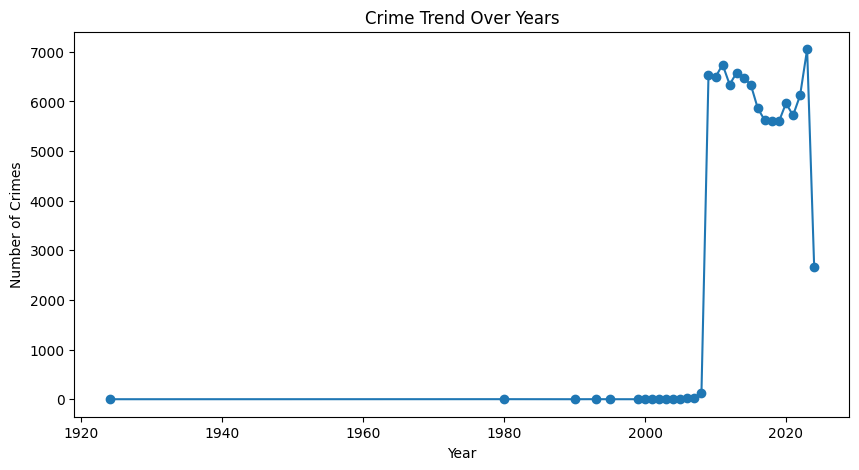

In [51]:
plt.figure(figsize=(10,5))

df['Year'].value_counts().sort_index().plot(
    kind='line',
    marker='o'
)

plt.title("Crime Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")

plt.show()

The dataset shows an increasing trend in reported crime incidents from 2000 to 2019. 
Reported crime incidents declined after 2020, which may indicate changes in crime patterns, reporting practices, or external factors affecting public activity.

In [52]:
df['Month'] = df['Crime_Start'].dt.month

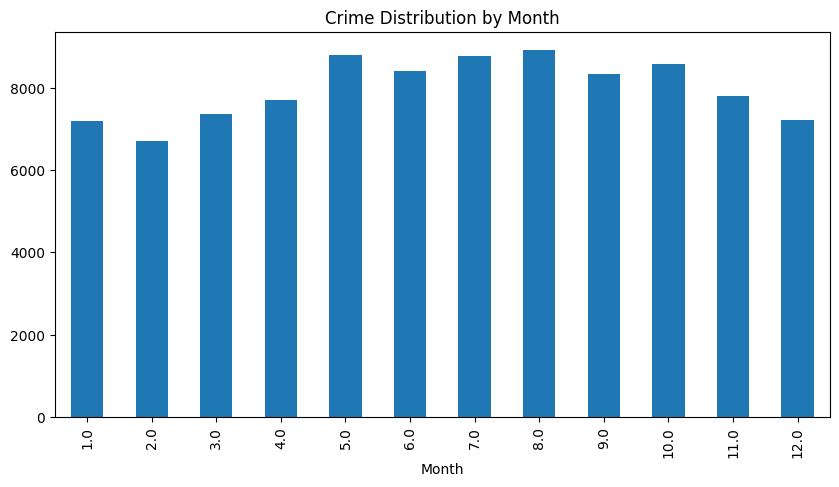

In [54]:
# 4. Crime distribution by month
df['Month'].value_counts().sort_index().plot(kind='bar',figsize=(10,5))
plt.title("Crime Distribution by Month")
plt.show()

Some months experience noticeably higher crime activity, indicating seasonal patterns.

In [ ]:
df['Repori']

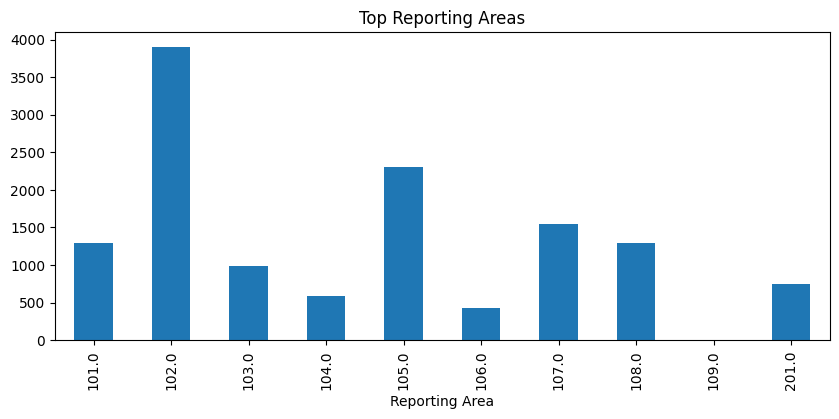

In [ ]:
# 5.Top reporting areas
df['Reporting Area'].value_counts().sort_index().head(10).plot(kind='bar',figsize=(10,4))
plt.title("Top 10 Reporting Areas")
plt.show()

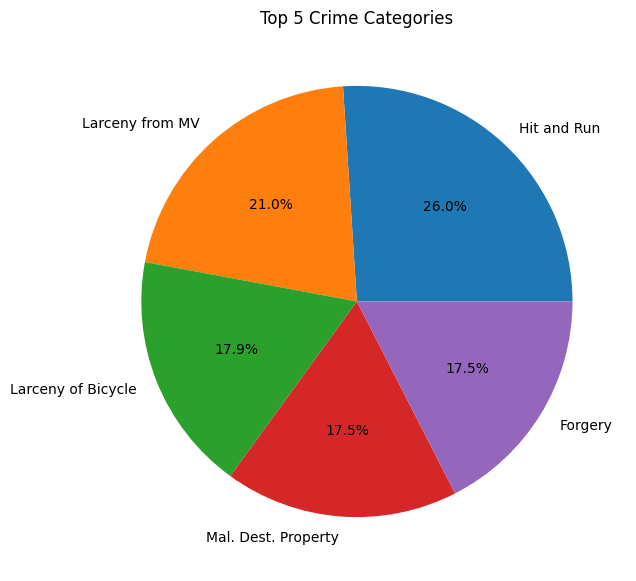

In [59]:
# 6.Crime type distribution
df['Crime'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%',figsize=(7,7))
plt.title("Top 5 Crime Categories")
plt.ylabel("")
plt.show()

## Key Observations

1. Certain crime categories occur much more frequently than others.
2. Crime incidents are concentrated in specific neighborhoods.
3. Reported crimes increased over the years and peaked around 2019–2020.
4. Crime activity varies across months, suggesting seasonal trends.
5. Some reporting areas experience significantly higher crime rates than others.

## Challenges Faced

- Missing values were present in multiple columns.
- The Crime Date Time column contained date-time ranges rather than single timestamps.
- Datetime conversion required extracting the start time from each record.
- Some records could not be converted and were handled appropriately.

## Conclusion

The Cambridge Crime dataset was successfully cleaned and analyzed. Missing values were handled, datetime issues were resolved, and multiple visualizations were created to identify crime patterns. The analysis revealed high-crime areas, common crime categories, temporal trends, and seasonal variations. These insights can support better decision-making in public safety and crime prevention.